In [8]:
#Save Final Dataset
df.to_csv(
    "../data/prescriptive_supply_chain.csv",
    index=False
)

In [7]:
#Total Savings
print(
    df["estimated_saving"].sum()
)

321759.982


In [6]:
#Cost Saving Estimation
def estimated_saving(row):
    if row["recommended_action"] == "Change Supplier":
        return row["cost_change"] * 0.40
    elif row["recommended_action"] == "Increase Inventory":
        return row["cost_change"] * 0.30
    elif row["recommended_action"] == "Use Express Shipping":
        return row["cost_change"] * 0.20
    else:
        return row["cost_change"] * 0.10

df["estimated_saving"] = df.apply(estimated_saving, axis=1)




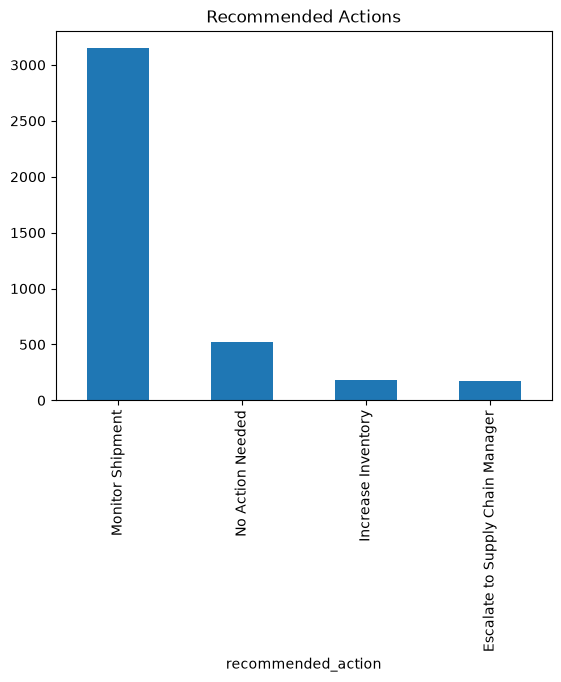

In [5]:
#Recommedation Distribution
df["recommended_action"].value_counts()

#Plot
import matplotlib.pyplot as plt

df["recommended_action"].value_counts().plot(
    kind="bar"
)

plt.title("Recommended Actions")

plt.show()

In [4]:
#Apply
df["recommended_action"] = df.apply(
    recommend_action,
    axis=1
)

In [3]:
#Recommendation Engine
def recommend_action(row):

    if row["prediction"] == 0:
        return "No Action Needed"

    if row["supplier_avg_delay"] > 5:
        return "Change Supplier"

    if row["stock_quantity"] < 100:
        return "Increase Inventory"

    if row["lead_time"] > 10:
        return "Use Express Shipping"

    if row["high_severity"] == 1:
        return "Escalate to Supply Chain Manager"

    return "Monitor Shipment"

In [2]:
# Day 7 - Prescriptive Analytics
#SupplyPrescript
#From Prediction to Action
#Import
import pandas as pd
import joblib
#Load Dataset
df = pd.read_csv("../data/feature_engineered_supply_chain.csv")
#Load Best MOdel
model = joblib.load("../models/xgboost_model.pkl")
#Predict Delay
features = [
    "shipment_quantity",
    "unit_price",
    "lead_time",
    "stock_quantity",
    "rating",
    "shipment_value",
    "supplier_avg_delay"
]

df["prediction"] = model.predict(df[features])
